In [1]:
from os import environ
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="ERROR", progress=False)

dataset_directory = Path(environ.get("SCARF_DOCS_DATA_DIR", "scarf_datasets"))
dataset_directory.mkdir(parents=True, exist_ok=True)

download_url = (
    "https://datasets.cellxgene.cziscience.com/"
    "3b751975-34bb-409a-a9b7-98380f0450ea.h5ad"
)
h5ad_path = dataset_directory / "binvignat_ra_pbmc.h5ad"
source_store = dataset_directory / "binvignat_ra_pbmc.zarr"

if not h5ad_path.exists():
    partial_path = h5ad_path.with_suffix(".h5ad.part")
    urlretrieve(download_url, partial_path)
    partial_path.replace(h5ad_path)

inspection = scarf.inspect_h5ad(str(h5ad_path))
assert inspection.matrixKey == "raw/X"
assert inspection.integerLike is True
assert (inspection.nCells, inspection.nFeatures) == (108_717, 21_648)

if not source_store.exists():
    with TemporaryDirectory(dir=dataset_directory) as conversion_directory:
        staged_store = Path(conversion_directory) / source_store.name
        reader = scarf.H5adReader.from_inspect(inspection)
        try:
            scarf.H5adToZarr(
                reader,
                zarr_loc=str(staged_store),
                nthreads=4,
            ).dump()
        finally:
            reader.h5.close()
        staged_store.replace(source_store)

In [2]:
source = scarf.DataStore(
    str(source_store),
    default_assay="RNA",
    min_features_per_cell=0,
    nthreads=4,
)

In [3]:
analysis_directory = TemporaryDirectory()
analysis_store = Path(analysis_directory.name) / "ra_batch_demo.zarr"

ds = scarf.mount_datastore(
    str(source_store),
    at=str(analysis_store),
    default_assay="RNA",
    min_features_per_cell=0,
    nthreads=4,
)

In [4]:
batch = ds.cells.fetch_all("batch").astype(str)
disease = ds.cells.fetch_all("disease").astype(str)
batch_values = np.unique(batch)
disease_values = np.unique(disease)

assert batch_values.size == 3
assert disease_values.size == 2

rng = np.random.default_rng(42)
selected = np.zeros(ds.cells.N, dtype=bool)

for batch_value in batch_values:
    for disease_value in disease_values:
        candidates = np.flatnonzero(
            (batch == batch_value) & (disease == disease_value)
        )
        assert candidates.size >= 1_500
        chosen = rng.choice(candidates, size=1_500, replace=False)
        selected[chosen] = True

assert selected.sum() == 9_000
ds.cells.insert(
    column_name="docs_ra_batch_demo",
    values=selected,
    overwrite=True,
)

pd.crosstab(batch[selected], disease[selected])

col_0,normal,rheumatoid arthritis
row_0,,
1,1500,1500
2,1500,1500
3,1500,1500


In [5]:
pipeline_options = {
    "cell_key": "docs_ra_batch_demo",
    "filtering": False,
    "hvg_count": 1_000,
    "pca_dims": 20,
    "neighbors_k": 21,
    "leiden": False,
    "cell_cycle": False,
    "paris": False,
    "doublets": False,
    "markers": False,
    "snapshot_columns": ("batch", "disease", "rough_annot"),
}

uncorrected = ds.pipeline.run(
    label="ra_uncorrected",
    **pipeline_options,
)
harmony = ds.pipeline.run(
    label="ra_harmony",
    harmony_batch_columns=["batch"],
    **pipeline_options,
)

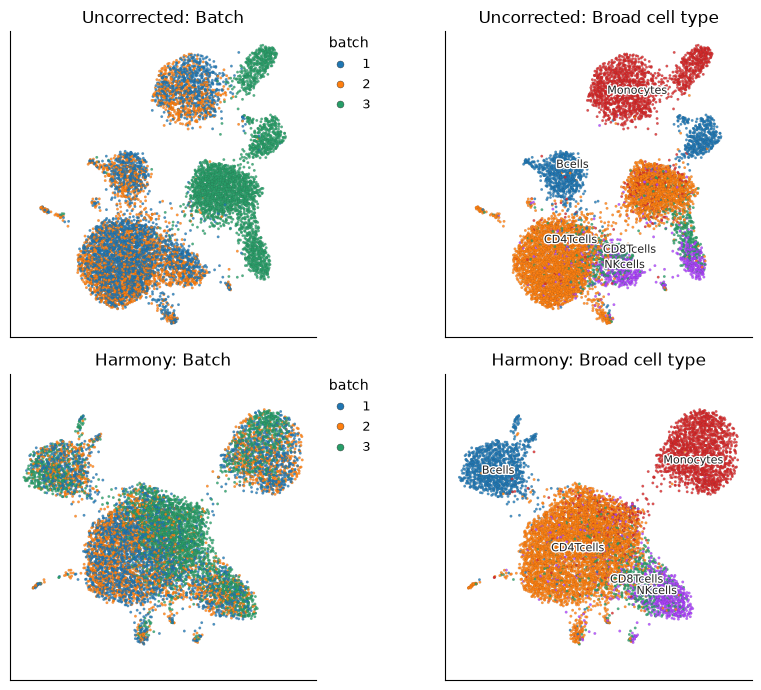

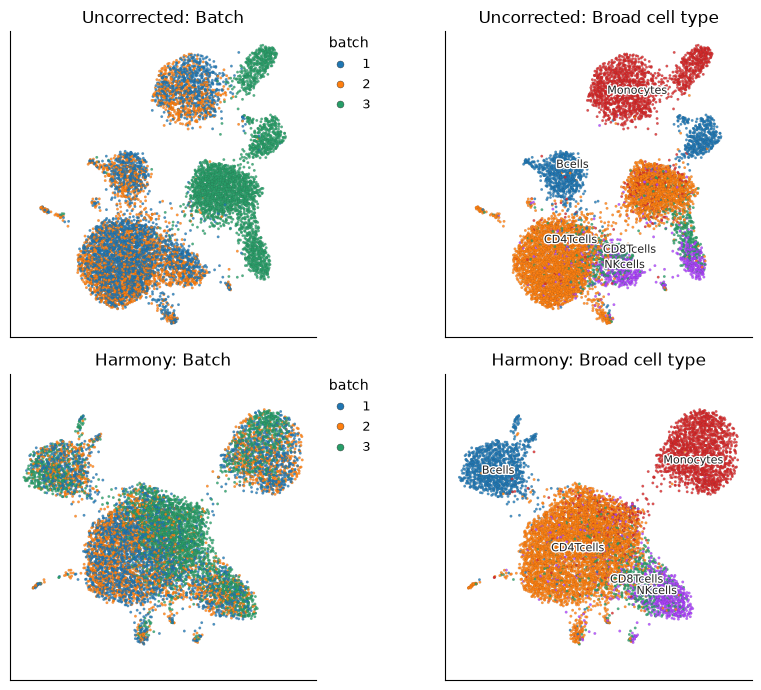

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(9, 7))
for row, (run_name, run) in enumerate(
    (("Uncorrected", uncorrected), ("Harmony", harmony))
):
    for column, (field, field_name) in enumerate(
        (("batch", "Batch"), ("rough_annot", "Broad cell type"))
    ):
        ds.plots.embedding(
            run=run,
            layout="umap",
            color_by=field,
            target=axes[row, column],
            legend_loc="right" if field == "batch" else "on_data",
            point_alpha=0.8,
            show=False,
        )
        axes[row, column].set_title(f"{run_name}: {field_name}")

figure.tight_layout()
figure

In [7]:
def integration_diagnostics(run):
    return {
        "iLISI (batch)": ds.metric_ilisi(
            batch_colname="batch",
            neighbors=run["neighbors"],
            perplexity=7,
        ),
        "cLISI (rough_annot)": ds.metric_clisi(
            annotation_column="rough_annot",
            neighbors=run["neighbors"],
            perplexity=7,
        ),
        "graph connectivity (rough_annot)": ds.metric_graph_connectivity(
            annotation_column="rough_annot",
            graph=run["connectivity_map"],
        ),
    }


score_frame = pd.DataFrame(
    {
        "Uncorrected": integration_diagnostics(uncorrected),
        "Harmony": integration_diagnostics(harmony),
    }
).T
score_frame.round(3)

,iLISI (batch),cLISI (rough_annot),graph connectivity (rough_annot)
Uncorrected,0.175,0.984,0.973
Harmony,0.407,0.980,0.973
